<a href="https://colab.research.google.com/github/sarthakkalra/ml-assessment-sarthak-kalra/blob/main/part_a/q3_feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd

# Load dataset (use raw GitHub link)
url = 'https://raw.githubusercontent.com/sarthakkalra/ml-assessment-sarthak-kalra/main/data/q3_retail_promotions.csv'
df = pd.read_csv(url)

# Inspect data
print("Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# Convert to datetime
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')

# Handle missing dates (if any)
df = df.dropna(subset=['transaction_date'])

# -------------------------------
# Feature Engineering
# -------------------------------

# Basic time features
df['year'] = df['transaction_date'].dt.year
df['month'] = df['transaction_date'].dt.month
df['day'] = df['transaction_date'].dt.day
df['day_of_week'] = df['transaction_date'].dt.dayofweek  # Monday=0

# Weekend indicator
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Month-end indicator
df['is_month_end'] = df['transaction_date'].dt.is_month_end.astype(int)

# Quarter
df['quarter'] = df['transaction_date'].dt.quarter

# Week of year
df['week_of_year'] = df['transaction_date'].dt.isocalendar().week.astype(int)

# Recency feature (very important in retail)
latest_date = df['transaction_date'].max()
df['days_since_last_transaction'] = (latest_date - df['transaction_date']).dt.days

# -------------------------------
# Final Output
# -------------------------------
print("\nData after feature engineering:")
df.head()

Shape: (1200, 9)

Missing Values:
 transaction_date       0
store_id               0
store_size             0
location_type          0
promotion_type         0
is_weekend             0
is_festival            0
competition_density    0
items_sold             0
dtype: int64

Data after feature engineering:


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day,day_of_week,is_month_end,quarter,week_of_year,days_since_last_transaction
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,1,5,0,1,52,1095
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,1,5,0,1,52,1095
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,2,6,0,1,52,1094
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,2,6,0,1,52,1094
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,3,0,0,1,1,1093


In [4]:
# Sort the data by transaction_date
df_sorted = df.sort_values(by='transaction_date').reset_index(drop=True)

# Calculate the split point (20% for test set)
split_point = int(len(df_sorted) * 0.8)

# Split the data into training and test sets
train_df = df_sorted.iloc[:split_point]
test_df = df_sorted.iloc[split_point:]

# Define features (X) and target (y)
X = df_sorted.drop('items_sold', axis=1)
y = df_sorted['items_sold']

X_train = X.iloc[:split_point]
X_test = X.iloc[split_point:]
y_train = y.iloc[:split_point]
y_test = y.iloc[split_point:]

print(f"Training set size: {len(train_df)}")
print(f"Test set size: {len(test_df)}")
print(f"Training date range: {train_df['transaction_date'].min()} to {train_df['transaction_date'].max()}")
print(f"Test date range: {test_df['transaction_date'].min()} to {test_df['transaction_date'].max()}")

Training set size: 960
Test set size: 240
Training date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# Identify categorical and numerical features
categorical_features = ['promotion_type', 'location_type', 'store_size']

# Drop 'transaction_date' as it's not needed for training directly
# and 'items_sold' is the target variable

# Ensure X_train and X_test do not contain 'transaction_date'
X_train_processed = X_train.drop(columns=['transaction_date'], errors='ignore')
X_test_processed = X_test.drop(columns=['transaction_date'], errors='ignore')

# Identify numerical features dynamically
numerical_features = X_train_processed.select_dtypes(include=np.number).columns.tolist()
numerical_features = [col for col in numerical_features if col not in categorical_features]

print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")

# Create the preprocessor using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns that are not specified
)

# Create a preprocessing pipeline (without a final model for now)
# A model can be added as the last step later.
preprocessing_pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fit the preprocessor on the training data
X_train_transformed = preprocessing_pipeline.fit_transform(X_train_processed)

# Apply the fitted preprocessor to both training and test data
X_test_transformed = preprocessing_pipeline.transform(X_test_processed)

print(f"\nShape of X_train_transformed: {X_train_transformed.shape}")
print(f"Shape of X_test_transformed: {X_test_transformed.shape}")

Categorical features: ['promotion_type', 'location_type', 'store_size']
Numerical features: ['store_id', 'is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day', 'day_of_week', 'is_month_end', 'quarter', 'week_of_year', 'days_since_last_transaction']

Shape of X_train_transformed: (960, 23)
Shape of X_test_transformed: (240, 23)



--- Linear Regression Model ---
Linear Regression RMSE: 26.9827
Linear Regression MAE: 20.9315


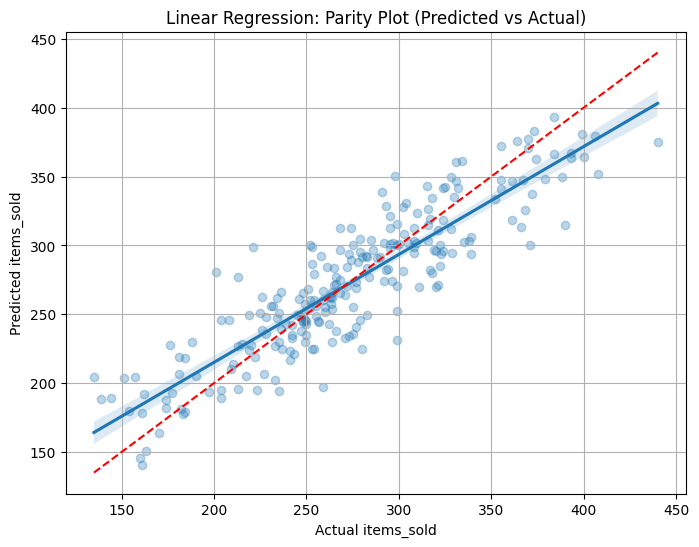


--- Random Forest Regressor Model ---
Random Forest Regressor RMSE: 30.4629
Random Forest Regressor MAE: 23.7012


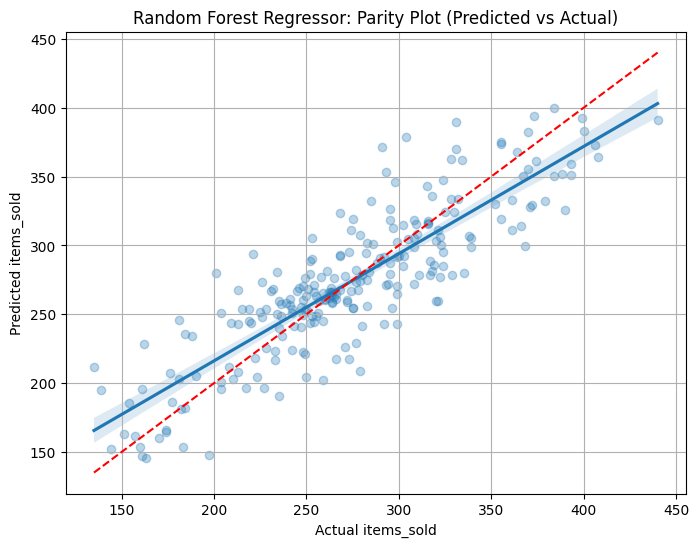


--- Random Forest Feature Importances ---
Top 5 most influential features:
num__is_festival            0.173026
cat__store_size_small       0.165424
cat__location_type_urban    0.108626
num__day_of_week            0.079296
num__is_weekend             0.061458


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# --- Linear Regression Model ---
print("\n--- Linear Regression Model ---")

# Create a full pipeline with preprocessing and Linear Regression
linear_regression_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Fit the pipeline on the training data
linear_regression_pipeline.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred_lr = linear_regression_pipeline.predict(X_test_processed)

# Evaluate the model
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression RMSE: {rmse_lr:.4f}")
print(f"Linear Regression MAE: {mae_lr:.4f}")

# Parity Plot for Linear Regression
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred_lr, scatter_kws={'alpha':0.3})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.title("Linear Regression: Parity Plot (Predicted vs Actual)")
plt.grid(True)
plt.show()

# --- Random Forest Regressor Model ---
print("\n--- Random Forest Regressor Model ---")

# Create a full pipeline with preprocessing and Random Forest Regressor
# Using n_estimators=100 as a reasonable default for demonstration
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

# Fit the pipeline on the training data
random_forest_pipeline.fit(X_train_processed, y_train)

# Make predictions on the test set
y_pred_rf = random_forest_pipeline.predict(X_test_processed)

# Evaluate the model
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest Regressor RMSE: {rmse_rf:.4f}")
print(f"Random Forest Regressor MAE: {mae_rf:.4f}")

# Parity Plot for Random Forest Regressor
plt.figure(figsize=(8, 6))
sns.regplot(x=y_test, y=y_pred_rf, scatter_kws={'alpha':0.3})
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual items_sold")
plt.ylabel("Predicted items_sold")
plt.title("Random Forest Regressor: Parity Plot (Predicted vs Actual)")
plt.grid(True)
plt.show()

# --- Feature Importances from Random Forest ---
print("\n--- Random Forest Feature Importances ---")

# Get feature names after preprocessing
preprocessed_feature_names = random_forest_pipeline.named_steps['preprocessor'].get_feature_names_out()

# Get feature importances from the trained Random Forest model
feature_importances = random_forest_pipeline.named_steps['regressor'].feature_importances_

# Create a pandas Series for easy sorting and display
feature_importance_series = pd.Series(feature_importances, index=preprocessed_feature_names)

# Sort feature importances in descending order
sorted_importances = feature_importance_series.sort_values(ascending=False)

print("Top 5 most influential features:")
print(sorted_importances.head(5).to_string())